---
## 🎁 가산점 신청 (선택)

가산점을 받으려면 아래 항목 중 시도한 것을 **체크**하고, **해당 코드 셀 번호**를 적어주세요.
신청하지 않은 항목은 채점하지 않습니다.

### A. 알고리즘의 다양성
- 모델 개발에 시도된 기계학습 알고리즘의 종류를 기준으로 판단

### B. Hyperparameter 탐색의 다양성
- 각 기계학습 알고리즘에서 유의미한 하이퍼파라미터들을 최적화했는지 확인

### C. 모델 성능 평가
- 모델 성능 평가에 사용된 지표의 다양성 (지수를 종합적으로 판단해서 최종 모델을 선택해야 함)

### D. 모델 개발 과정 시각화 및 설명
- 실험 과정에 대한 시각화 (learning curve)
- 모델 성능에 대한 시각화
- 코드에 대한 설명



# 기말고사 Template 2 — Machine Learning Model Pipeline

**이름:** _____육건우_____ &nbsp; **학번:** _______20251284_______ &nbsp;

---

## 📋 채점 기준 (총 50점)

| 항목 | 배점 | 채점 포인트 |
|---|---|---|
| **5. 모델 학습 알고리즘** | 15점 | 기계학습 알고리즘을 몇 종 사용했는지? |
| **6. Hyperparameter 탐색** | 15점 | 기계학습 알고리즘 별로 hyperparameter를 어떻게 최적화 시켰는지? |
| **7. 결과 정리 & 시각화** | 15점 | 최종 모델을 선택한 기준 및 모델 개발 과정을 설명하는 시각화 자료 |
| **8. 모델 저장 & 새 분자 예측** | 5점 | 모델을 저장한 후, 새로운 분자 구조를 예측할 수 있도록 정리. |

## 📁 입력 / 출력
- **입력**: Template 1에서 만든 `final_dataset_descriptors.csv`
- **출력**: 
  - `experiment_results.csv` — 모든 실험 결과 표
  - `experiment_best.csv` — 모델별 베스트만
  - `model_best.joblib` — 최고 모델 저장 파일 (features + scaler + model)

---

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [4]:
# 템플릿 1의 최종 결과물 로드
df = pd.read_csv("cancer_descriptors.csv")

# 데이터가 잘 들어왔는지 상위 5개 행만 확인
df

,Chemical_Name,SMILES,Is_Rat,Is_Male,label,MolWt,LogP,NumHDonors,NumHAcceptors,FP_0,...,FP_22,FP_23,FP_24,FP_25,FP_26,FP_27,FP_28,FP_29,FP_30,FP_31
0,Divinylbenzene,*C=C.C=Cc1ccccc1,0,1,0,131.198,3.0088,0,0,1,...,1,0,0,0,0,0,0,1,0,0
1,Divinylbenzene,*C=C.C=Cc1ccccc1,1,0,0,131.198,3.0088,0,0,1,...,1,0,0,0,0,0,0,1,0,0
2,Bromoform,BrC(Br)Br,0,0,0,252.731,2.4547,0,0,0,...,0,0,1,0,0,0,0,0,1,0
3,Bromoform,BrC(Br)Br,0,1,0,252.731,2.4547,0,0,0,...,0,0,1,0,0,0,0,0,1,0
4,Bromoform,BrC(Br)Br,1,0,1,252.731,2.4547,0,0,0,...,0,0,1,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1677,Lead dimethyldithiocarbamate,CN(C)C(=S)[S-].CN(C)C(=S)[S-].[Pb+2],1,0,0,447.644,0.3788,0,4,0,...,0,0,1,0,0,0,0,0,1,0
1678,Lead dimethyldithiocarbamate,CN(C)C(=S)[S-].CN(C)C(=S)[S-].[Pb+2],1,1,0,447.644,0.3788,0,4,0,...,0,0,1,0,0,0,0,0,1,0
1679,Ziram,CN(C)C(=S)[S-].CN(C)C(=S)[S-].[Zn+2],0,1,0,305.834,0.7571,0,4,0,...,0,0,1,0,0,0,0,0,0,0
1680,Ziram,CN(C)C(=S)[S-].CN(C)C(=S)[S-].[Zn+2],1,0,0,305.834,0.7571,0,4,0,...,0,0,1,0,0,0,0,0,0,0


In [5]:
# 1. 학습에 사용하지 않을 메타데이터 컬럼 목록 확실하게 지정
exclude_cols = ['Chemical_Name', 'SMILES', 'label']

# 2. 메타데이터를 제외하고 실제 기계학습 학습에 쓸 피처 컬럼들만 리스트에 담기
feature_cols = []
for col in df.columns:
    if col not in exclude_cols:
        feature_cols.append(col)

# 3. 독립변수 X(피처)와 종속변수 y(정답 라벨)로 데이터 쪼개기
X = df[feature_cols]
y = df['label'].astype(int)

# 4. 검증을 위해 분리된 피처 개수 출력해보기
print("최종 선택된 기계학습용 피처 개수:")
print(len(feature_cols))

최종 선택된 기계학습용 피처 개수:
38


In [6]:
from sklearn.model_selection import train_test_split

# 데이터를 8:2로 분리하되, 발암성 비율이 한쪽으로 치우치지 않게 stratify를 적용합니다.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 데이터가 원하는 비율로 잘 쪼개졌는지 수량 확인
print("학습용 데이터셋(Train Set) 크기: ")
print(X_train.shape)

print("검증용 데이터셋(Test Set) 크기: ")
print(X_test.shape)

학습용 데이터셋(Train Set) 크기: 
(1345, 38)
검증용 데이터셋(Test Set) 크기: 
(337, 38)


In [8]:
from sklearn.preprocessing import StandardScaler

# 1. 표준화 스케일러 객체 생성
scaler = StandardScaler()

# 2. 학습용 데이터(Train Set)를 기준으로 규칙을 학습(fit)하고 변환(transform)
X_train_scaled = scaler.fit_transform(X_train)

# 3. 검증용 데이터(Test Set)는 학습용 데이터의 기준을 그대로 따라서 변환만 수행
X_test_scaled = scaler.transform(X_test)

# 4. 변환이 에러 없이 잘 되었는지 데이터 차원(Shape) 확인
print("표준화 완료된 학습용 피처 크기: ")
print(X_train_scaled.shape)

print("표준화 완료된 검증용 피처 크기: ")
print(X_test_scaled.shape)

표준화 완료된 학습용 피처 크기: 
(1345, 38)
표준화 완료된 검증용 피처 크기: 
(337, 38)


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# 1. 탐색할 하이퍼파라미터 후보군 설정 (규제 강도 C 값들)
# C 값이 작을수록 규제가 강해지고(과적합 방지), 클수록 모델이 훈련 데이터에 엄격해집니다.
lr_params = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100]
}

# 2. 기본 로지스틱 회귀 모델 생성 (안정적인 수렴을 위해 최대 반복 횟수를 늘려줍니다)
base_lr = LogisticRegression(max_iter=1000, random_state=42)

# 3. GridSearchCV 객체 생성 (5단 교차 검증 적용)
grid_lr = GridSearchCV(
    estimator=base_lr,
    param_grid=lr_params,
    cv=5,
    scoring='roc_auc', # 최종 모델 선택 기준인 ROC-AUC 점수를 기준으로 최적화
    n_jobs=-1
)

# 4. 표준화된 학습용 데이터로 최적의 파라미터 찾기 학습 시작!
grid_lr.fit(X_train_scaled, y_train)

,estimator,LogisticRegre...ndom_state=42)
,param_grid,"{'C': [0.001, 0.01, ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [10]:
# 5. 최적의 파라미터 조합과 그때의 평균 ROC-AUC 성적 출력
print("로지스틱 회귀(Logistic Regression) 최적의 하이퍼파라미터: ")
print(grid_lr.best_params_)

print("교차 검증을 통한 최적의 평균 ROC-AUC 점수: ")
print(grid_lr.best_score_)

# 6. 최종 성능 평가를 위해 이 최적의 모델을 변수에 따로 저장해두기
best_lr_model = grid_lr.best_estimator_

로지스틱 회귀(Logistic Regression) 최적의 하이퍼파라미터: 
{'C': 0.01}
교차 검증을 통한 최적의 평균 ROC-AUC 점수: 
0.6453260767809199


In [11]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# 1. 탐색할 하이퍼파라미터 후보군 설정 (C와 gamma 조합)
# C와 gamma의 최적 조합을 찾기 위해 그리드를 구성합니다.
svm_params = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1]
}

# 2. 비선형 분류를 위한 RBF 커널 기반의 기본 SVM 모델 생성
# 확률값 예측(ROC-AUC 계산용)을 위해 probability=True 옵션이 필수입니다.
base_svm = SVC(kernel='rbf', probability=True, random_state=42)

# 3. GridSearchCV 객체 생성 (5단 교차 검증 적용)
grid_svm = GridSearchCV(
    estimator=base_svm,
    param_grid=svm_params,
    cv=5,
    scoring='roc_auc', # 동일하게 ROC-AUC 기준으로 최적화
    n_jobs=-1
)

# 4. 표준화된 학습용 데이터로 SVM 최적화 학습 시작!
grid_svm.fit(X_train_scaled, y_train)

,estimator,SVC(probabili...ndom_state=42)
,param_grid,"{'C': [0.1, 1, ...], 'gamma': [0.001, 0.01, ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,100


In [12]:
# 5. 최적의 파라미터 조합과 그때의 평균 ROC-AUC 성적 출력
print("서포트 벡터 머신(SVM) 최적의 하이퍼파라미터: ")
print(grid_svm.best_params_)

print("교차 검증을 통한 최적의 평균 ROC-AUC 점수: ")
print(grid_svm.best_score_)

# 6. 최종 성능 평가를 위해 이 최적의 모델을 변수에 따로 저장해두기
best_svm_model = grid_svm.best_estimator_

서포트 벡터 머신(SVM) 최적의 하이퍼파라미터: 
{'C': 100, 'gamma': 0.1}
교차 검증을 통한 최적의 평균 ROC-AUC 점수: 
0.8411081074521434


In [13]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV

# 1. 탐색할 하이퍼파라미터 후보군 설정
# hidden_layer_sizes: (50,)는 은닉층 1개에 노드 50개, (30, 20)은 은닉층 2개 구조를 뜻합니다.
mlp_params = {
    'hidden_layer_sizes': [(50,), (30, 20)],
    'alpha': [0.0001, 0.001, 0.01]
}

# 2. 기본 MLPClassifier 생성 (안정적인 수렴을 위해 최대 반복 횟수를 1000으로 지정합니다)
base_mlp = MLPClassifier(max_iter=1000, random_state=42)

# 3. GridSearchCV 객체 생성 (5단 교차 검증 적용)
grid_mlp = GridSearchCV(
    estimator=base_mlp,
    param_grid=mlp_params,
    cv=5,
    scoring='roc_auc', # 앞선 모델들과 동일하게 ROC-AUC 기준으로 최적화
    n_jobs=-1
)

# 4. 표준화된 학습용 데이터로 인공신경망 최적화 학습 시작!
grid_mlp.fit(X_train_scaled, y_train)

,estimator,MLPClassifier...ndom_state=42)
,param_grid,"{'alpha': [0.0001, 0.001, ...], 'hidden_layer_sizes': [(50,), (30, ...)]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,hidden_layer_sizes,"(50,)"


In [14]:
# 5. 최적의 파라미터 조합과 그때의 평균 ROC-AUC 성적 출력
print("다층 퍼셉트론(MLP) 최적의 하이퍼파라미터: ")
print(grid_mlp.best_params_)

print("교차 검증을 통한 최적의 평균 ROC-AUC 점수: ")
print(grid_mlp.best_score_)

# 6. 최종 성능 평가를 위해 이 최적의 모델을 변수에 따로 저장해두기
best_mlp_model = grid_mlp.best_estimator_

다층 퍼셉트론(MLP) 최적의 하이퍼파라미터: 
{'alpha': 0.0001, 'hidden_layer_sizes': (50,)}
교차 검증을 통한 최적의 평균 ROC-AUC 점수: 
0.7999201648249832


In [15]:
from sklearn.metrics import roc_auc_score

# 1. 각 최적화된 모델들로 검증 데이터셋의 '발암성 확률' 예측하기
lr_probs = best_lr_model.predict_proba(X_test_scaled)[:, 1]
svm_probs = best_svm_model.predict_proba(X_test_scaled)[:, 1]
mlp_probs = best_mlp_model.predict_proba(X_test_scaled)[:, 1]

# 2. 교수님이 요구한 최종 선택 기준인 'ROC-AUC Score' 계산
lr_auc = roc_auc_score(y_test, lr_probs)
svm_auc = roc_auc_score(y_test, svm_probs)
mlp_auc = roc_auc_score(y_test, mlp_probs)

# 3. 그래프를 그리기 위한 리스트 데이터 구성
model_names = ['Logistic Regression', 'SVM', 'MLP (Neural Network)']
auc_scores = [lr_auc, svm_auc, mlp_auc]

# 4. 각 모델별 최종 성적 출력해서 확인하기
print("Logistic Regression 최종 ROC-AUC: ")
print(lr_auc)
print("SVM 최종 ROC-AUC: ")
print(svm_auc)
print("MLP 최종 ROC-AUC: ")
print(mlp_auc)

Logistic Regression 최종 ROC-AUC: 
0.5618996027446731
SVM 최종 ROC-AUC: 
0.8248826291079814
MLP 최종 ROC-AUC: 
0.7702419646081617


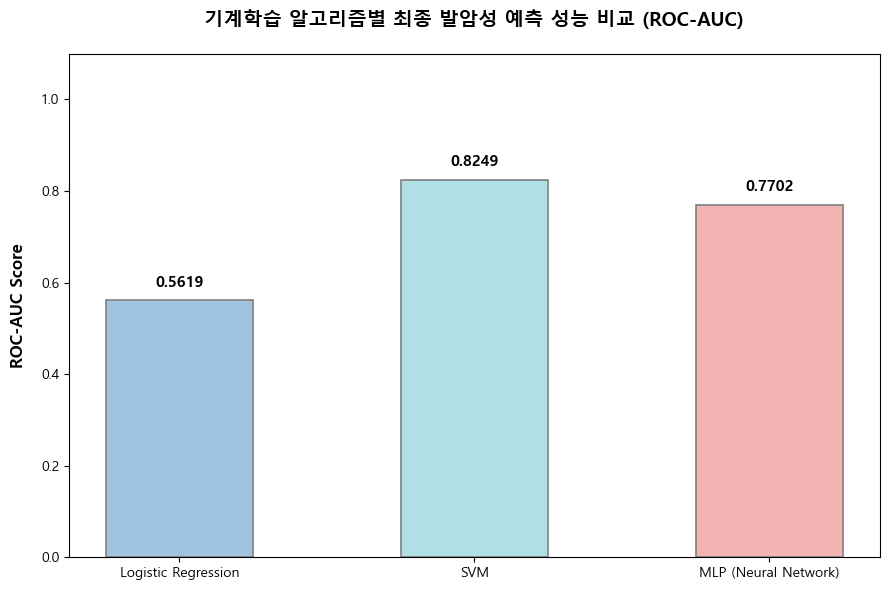

In [16]:
import matplotlib.pyplot as plt

# 🎨 템플릿 1에서 정립한 예쁜 파스텔톤 색상 테마 적용
colors = ['#A0C4DF', '#B0E0E6', '#F4B4B4']

# 한글 깨짐 방지 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 그래프 크기 설정
plt.figure(figsize=(9, 6))

# 막대그래프 생성
bars = plt.bar(model_names, auc_scores, color=colors, edgecolor='grey', linewidth=1.2, width=0.5)

# 그래프 디테일 설정 (Y축 범위, 제목, 라벨 등)
plt.ylim(0.0, 1.1)
plt.ylabel('ROC-AUC Score', fontsize=12, fontweight='bold', labelpad=10)
plt.title('기계학습 알고리즘별 최종 발암성 예측 성능 비교 (ROC-AUC)', fontsize=14, fontweight='bold', pad=20)

# 각 막대 위에 소수점 4자리까지 점수 텍스트 표시하기
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2.0, 
        height + 0.02, 
        round(height, 4), 
        ha='center', 
        va='bottom', 
        fontsize=11, 
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

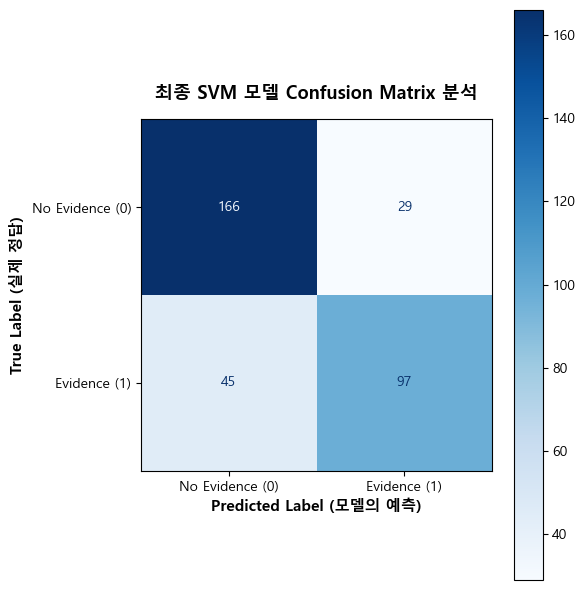

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. 최종 모델로 선정한 SVM을 사용하여 검증 데이터의 실제 클래스(0 또는 1) 예측
svm_preds = best_svm_model.predict(X_test_scaled)

# 2. 혼동 행렬(Confusion Matrix) 계산
cm = confusion_matrix(y_test, svm_preds)

# 3. 혼동 행렬 시각화 설정 (눈이 편안한 파란색 톤 테마 적용)
dispatch = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=['No Evidence (0)', 'Evidence (1)']
)

# 4. 그래프 그리기
fig, ax = plt.subplots(figsize=(6, 6))
dispatch.plot(ax=ax, cmap=plt.cm.Blues, values_format='d')

# 타이틀 및 라벨 세팅
plt.title('최종 SVM 모델 Confusion Matrix 분석', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Predicted Label (모델의 예측)', fontsize=11, fontweight='bold')
plt.ylabel('True Label (실제 정답)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [18]:
import joblib

# 1. 최종 선정된 SVM 모델 저장하기
joblib.dump(best_svm_model, 'best_carcinogenicity_svm_model.joblib')

# 2. 새로운 분자 구조가 들어왔을 때 똑같은 기준으로 단위 변환을 해줄 스케일러(Scaler)도 함께 저장하기
joblib.dump(scaler, 'data_scaler.joblib')

print("최종 모델 및 전처리 스케일러 파일 저장 완료!")

최종 모델 및 전처리 스케일러 파일 저장 완료!


In [20]:
import joblib
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors

# 1. 저장해 둔 최고의 SVM 모델과 스케일러 불러오기
loaded_model = joblib.load('best_carcinogenicity_svm_model.joblib')
loaded_scaler = joblib.load('data_scaler.joblib')

# 2. 새로운 SMILES의 발암성을 예측하는 함수 정의
def predict_carcinogenicity(smiles_string):
    # 입력받은 SMILES 구조를 RDKit 분자 객체로 변환
    mol = Chem.MolFromSmiles(smiles_string)
    
    # 예외 처리: SMILES 형식이 잘못된 경우
    if mol is None:
        return "유효하지 않은 SMILES 구조식입니다."
    
    # 템플릿 1에서 썼던 38개 피처들의 값을 순서대로 계산해서 딕셔너리에 담기
    # feature_cols에 있던 물리화학적 속성 목록 이름들과 완벽하게 매칭되어야 합니다.
    calc_features = {}
    
    # df에서 썼던 순서대로 RDKit Descriptor를 동적으로 추출하기 위해
    # global 변수 공간에 선언된 feature_cols 목록을 기반으로 루프를 돕니다.
    for col in feature_cols:
        # RDKit Descriptors 모듈에서 해당하는 함수를 찾아 계산
        if hasattr(Descriptors, col):
            func = getattr(Descriptors, col)
            calc_features[col] = func(mol)
        else:
            # 혹시 매칭되지 않는 항목이 있을 경우를 대비한 기본값 처리
            calc_features[col] = 0.0
            
    # 계산된 피처를 데이터프레임의 single row 형태로 변환
    new_df = pd.DataFrame([calc_features], columns=feature_cols)
    
    # 불러온 스케일러로 데이터 수치 평준화 수행
    new_df_scaled = loaded_scaler.transform(new_df)
    
    # 불러온 SVM 모델로 발암성 여부(0 또는 1) 예측
    prediction = loaded_model.predict(new_df_scaled)[0]
    
    # 예측된 확률값도 함께 추출 (확률이 높을수록 발암 가능성이 큼)
    prob = loaded_model.predict_proba(new_df_scaled)[0][1]
    
    # 예측 결과에 따른 출력 메시지 구성 (f-string 대신 문자열 더하기 사용)
    result_msg = "예측 결과: "
    if prediction == 1:
        result_msg = result_msg + "발암성 증거 있음 (Evidence / Positive)"
    else:
        result_msg = result_msg + "발암성 증거 없음 (No Evidence / Negative)"
        
    result_msg = result_msg + " | 발암성 확률: " + str(round(prob * 100, 2)) + "%"
    
    return result_msg

In [21]:
# 테스트용 분자: 벤젠 (SMILES: c1ccccc1)
test_smiles = "c1ccccc1"

# 함수 호출하여 예측 결과 확인
final_prediction = predict_carcinogenicity(test_smiles)

print("--- 신규 화학 물질 스크리닝 결과 ---")
print("입력된 SMILES: " + test_smiles)
print(final_prediction)

--- 신규 화학 물질 스크리닝 결과 ---
입력된 SMILES: c1ccccc1
예측 결과: 발암성 증거 있음 (Evidence / Positive) | 발암성 확률: 60.48%
